<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/2000_election_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Bunderson - Written Report Ch 8

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

head(ex0825)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,County,Buchanan2000,Bush2000
,<chr>,<int>,<int>
1,Alachua,262,34062
2,Baker,73,5610
3,Bay,248,38637
4,Bradford,65,5413
5,Brevard,570,115185
6,Broward,789,177279


In [ ]:
data_no_pb <- ex0825[ex0825$County != "Palm Beach", ]

Bush <- data_no_pb$Bush2000
Buchanan <- data_no_pb$Buchanan2000

logBuchanan <- log(Buchanan)
logBush <- log(Bush)

#Introduction
The 2000 U.S. presidential election between Al Gore and George W. Bush was one of the closest and most controversial elections in American history. The outcome ultimately depended on the state of Florida, where the margin of victory was extremely small and led to recounts and widespread scrutiny of the voting process. One major concern arose in Palm Beach County, where a confusing “butterfly ballot” design may have caused voters to mistakenly select the Reform Party candidate, Pat Buchanan, instead of their intended choice.

This analysis investigates whether Buchanan received an unusually high number of votes in Palm Beach County compared to what would be expected based on voting patterns in other Florida counties. Specifically, we examine the relationship between votes for Bush and votes for Buchanan across all counties, using this relationship to predict the expected number of Buchanan votes in Palm Beach County. By comparing the observed value to this prediction, we can assess whether there is statistical evidence supporting the claim of voting errors.

To carry out this investigation, a regression analysis is performed using county-level voting data. Because vote counts can vary widely in magnitude across counties, a transformation may be applied to stabilize variability and better satisfy modeling assumptions. The results will be used to construct a prediction interval for Buchanan’s votes in Palm Beach County, allowing us to evaluate whether the observed count is unusually large. This, in turn, provides insight into the possible extent of miscast votes due to the ballot design.

#Graphical Analysis

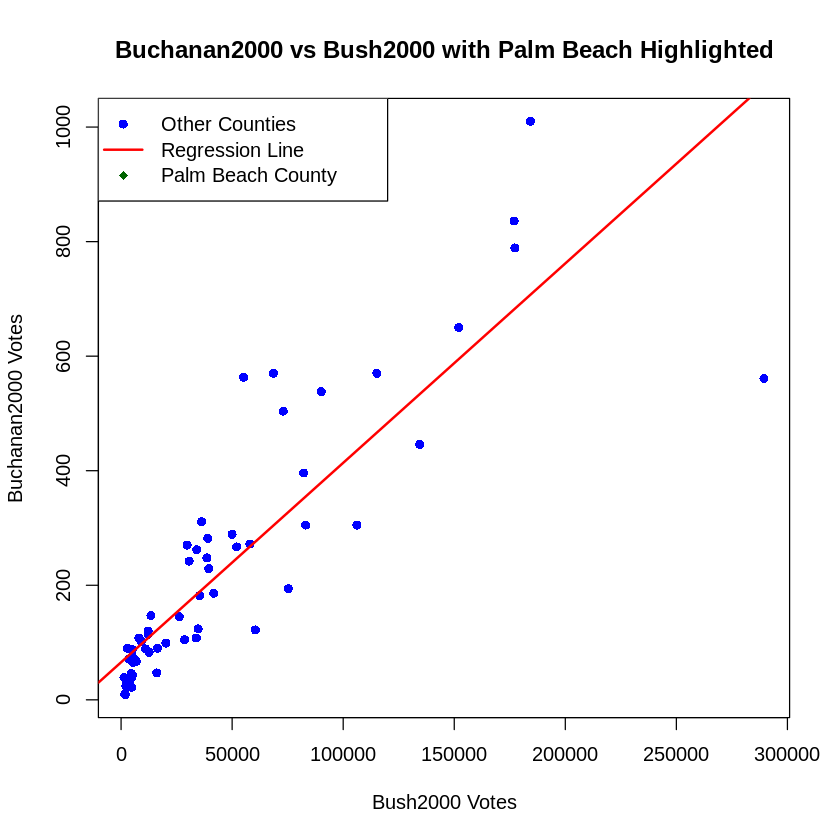

In [ ]:
# Create the scatterplot for all counties using original data
plot(Bush, Buchanan,
     main = "Buchanan2000 vs Bush2000 with Palm Beach Highlighted",
     xlab = "Bush2000 Votes",
     ylab = "Buchanan2000 Votes",
     col = "blue", pch = 16)

# Add the regression line for the original data
abline(lm(Buchanan ~ Bush), col = "red", lwd = 2)

# Add a legend
legend("topleft",
       legend = c("Other Counties", "Regression Line", "Palm Beach County"),
       col = c("blue", "red", "darkgreen"),
       pch = c(16, NA, 18),
       lwd = c(NA, 2, NA),
       lty = c(NA, 1, NA))

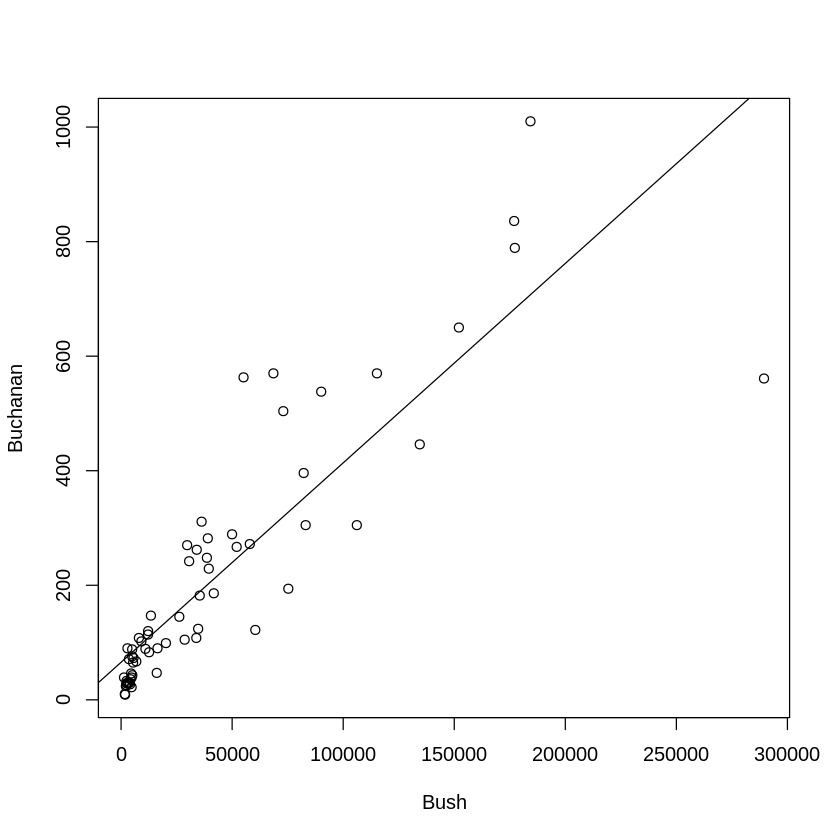

In [ ]:
plot(Bush, Buchanan)

abline(lm(Buchanan ~ Bush))

This is not great; the data is very squished. Let's explore some common transformations to see if we can get a "better" looking graph.

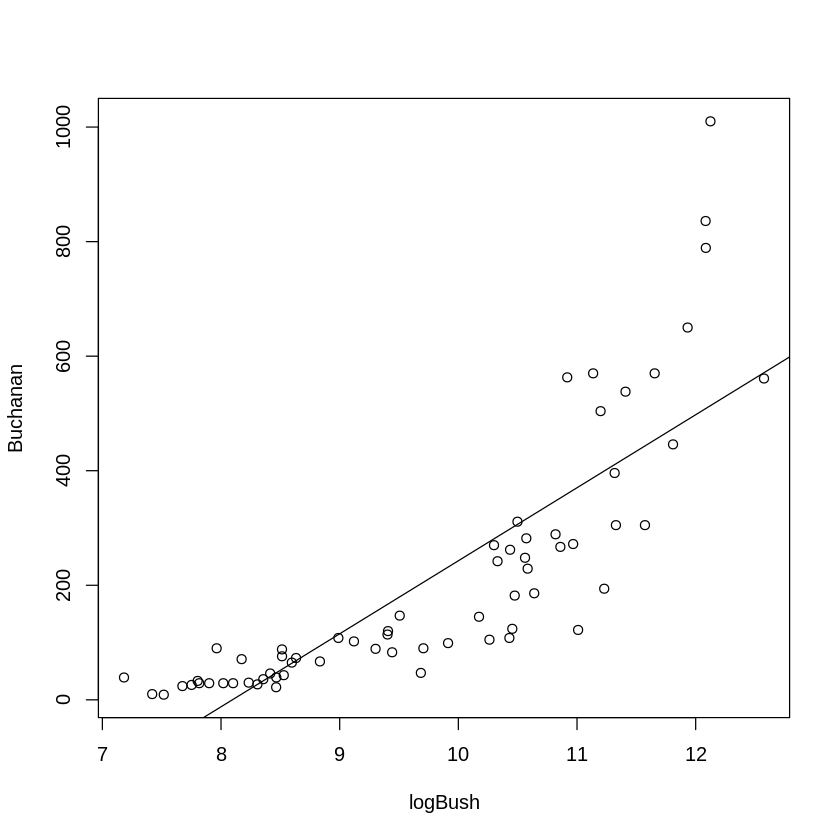

In [ ]:
# just logging input variable

plot(logBush, Buchanan)
abline(lm(Buchanan ~ logBush))

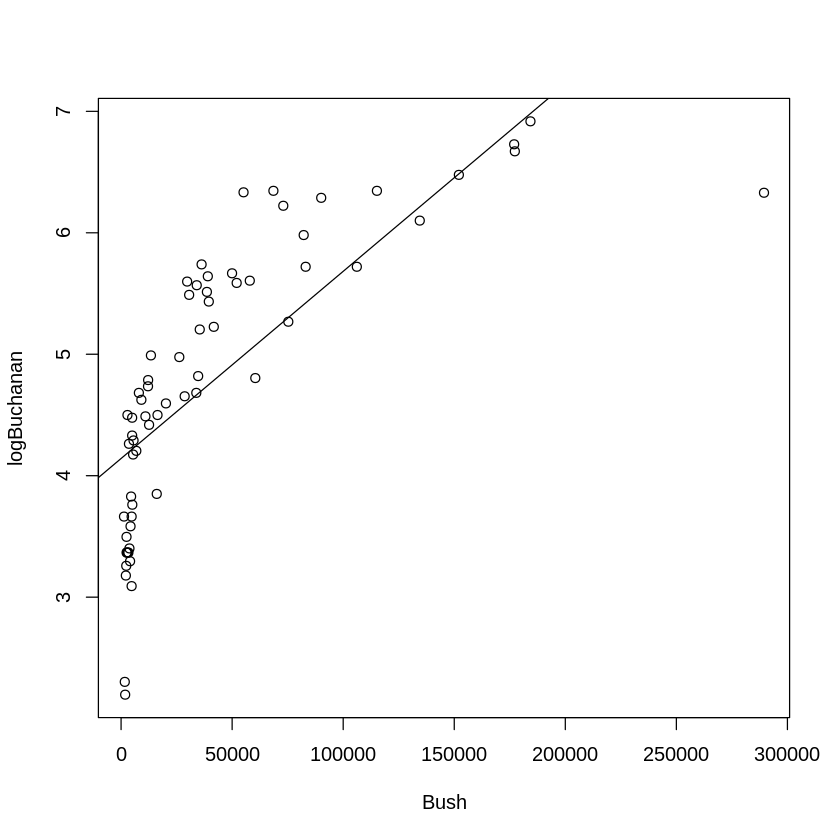

In [ ]:
# log the response variable

plot(Bush, logBuchanan)
abline(lm(logBuchanan ~ Bush))

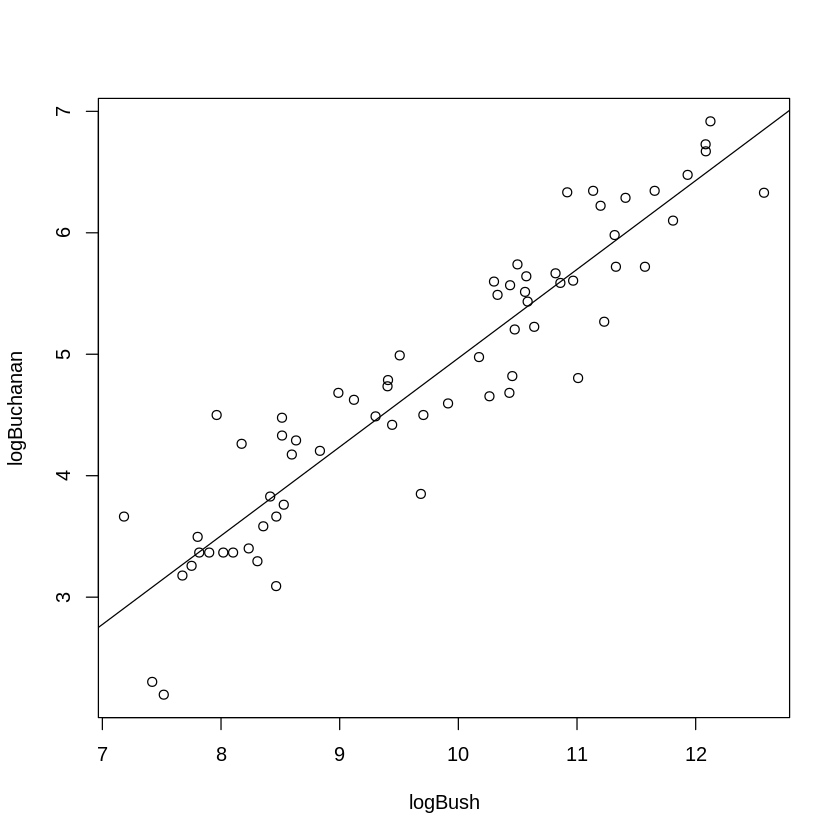

In [ ]:
# logging the response and input

plot(logBush, logBuchanan)
abline(lm(logBuchanan ~ logBush))

That looks much better!

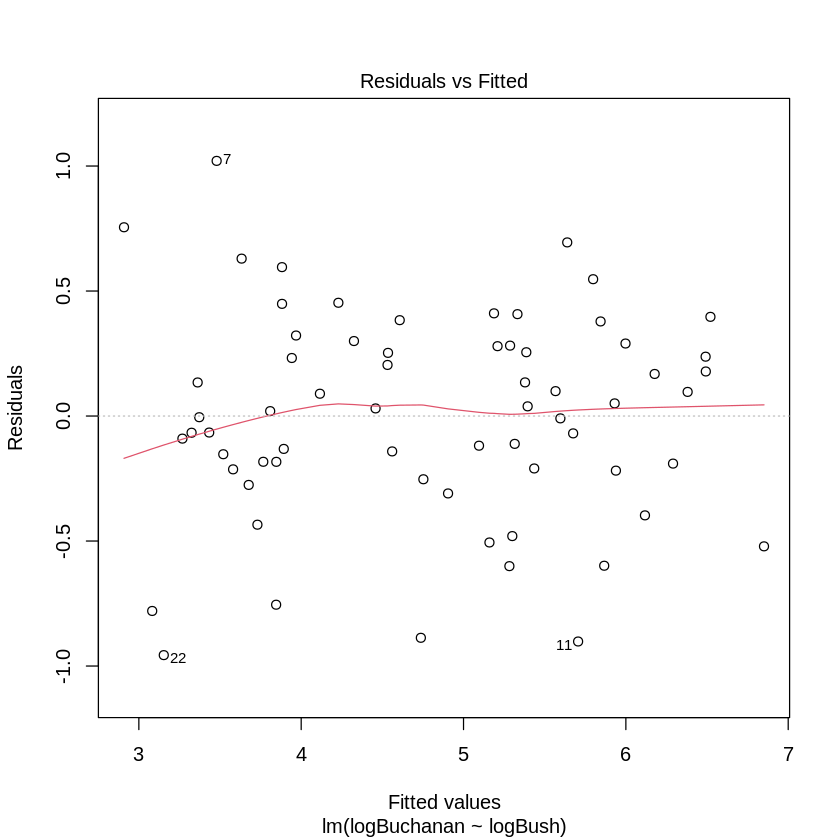

In [ ]:
log_log <- lm(logBuchanan ~ logBush, data = data_no_pb)
plot(log_log, which = 1)

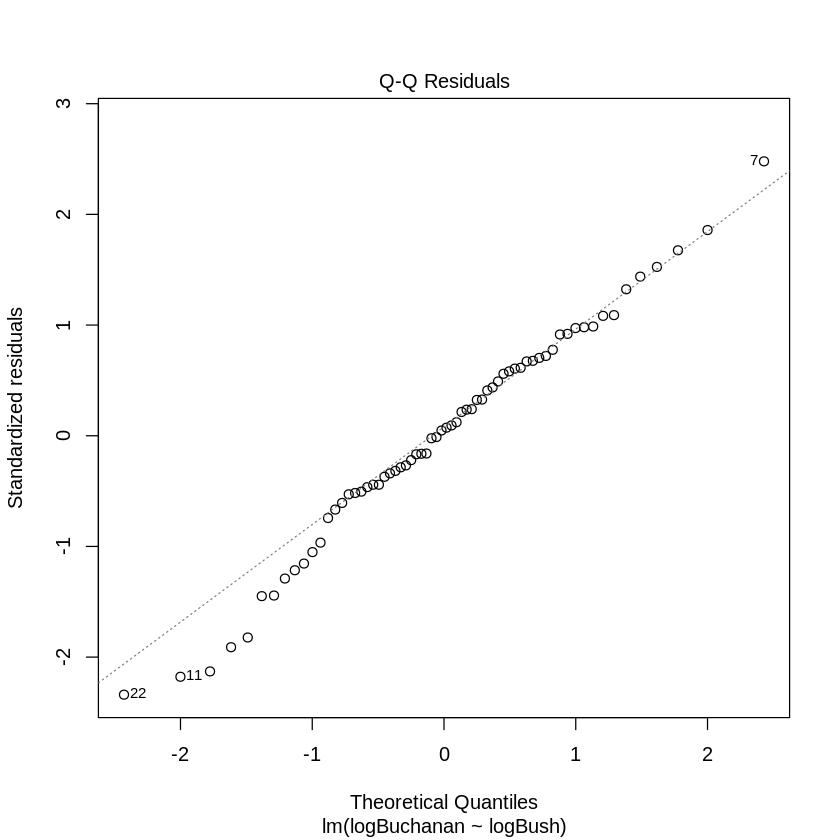

In [ ]:
plot(log_log, which = 2) # which = 2 specifically requests the Normal Q-Q plot

#Assumptions
#Independent
Each observation is from a different person's ballot. Independence is fulfilled and we can continue with the analysis.

#Normality of Residuals


	Shapiro-Wilk normality test

data:  resid(log_log)
W = 0.98612, p-value = 0.6718


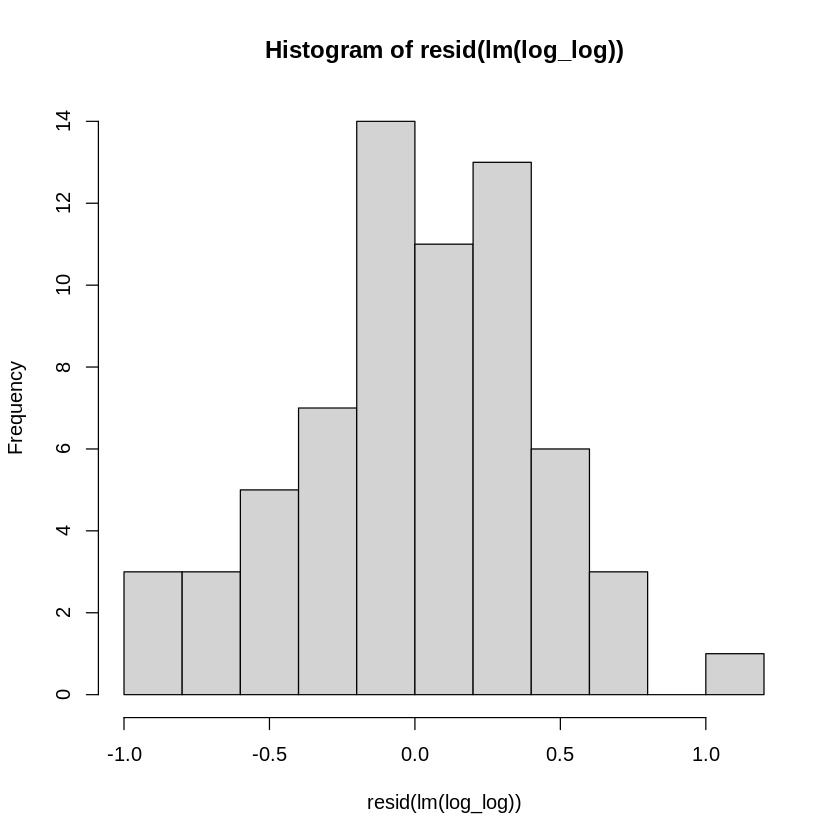

In [ ]:
hist(resid(lm(log_log)))
shapiro.test(resid(log_log))

The null hypothesis for the Shapiro-Wilk test is normality of residuals, and the alternative is non-normality. With a p-value of 0.07066, we cautiously fail to reject the null hypothesis, but we can conclude that the normality assumption is met.

#Constant Variance

In [ ]:
install.packages("lawstat")
library(lawstat)

residuals_log_log <- resid(log_log)
fitted_values_log_log <- fitted(log_log)

num_groups <- 3
groups_for_levene <- cut(fitted_values_log_log, breaks = num_groups, include.lowest = TRUE, labels = FALSE)

levene.test(y = residuals_log_log, group = as.factor(groups_for_levene))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Kendall’, ‘mvtnorm’, ‘Rdpack’





	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  residuals_log_log
Test Statistic = 0.21068, p-value = 0.8106


With a null hypothesis of constant variance and an alternative hypothesis of non-constant variance and a p-value of 0.7688, we fail to reject the null hypothesis. We can continue with the statistical methods because we can conclude that the constant variance assumption is met with the Log transformed data.

#Statistical Conclusion

In [ ]:
summary(log_log)


Call:
lm(formula = logBuchanan ~ logBush, data = data_no_pb)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.95631 -0.21236  0.02503  0.28102  1.02056 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.34149    0.35442  -6.607 9.07e-09 ***
logBush      0.73096    0.03597  20.323  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4198 on 64 degrees of freedom
Multiple R-squared:  0.8658,	Adjusted R-squared:  0.8637 
F-statistic:   413 on 1 and 64 DF,  p-value: < 2.2e-16


**Equation of model:**

$$y = e^{-2.34149} x^{0.73096}$$

Might as well calculate that constant and simplify the equation. Doing that we approximately get:

$$y = 0.096184 x^{0.73096}$$

With a p-value of nearly 0, we can reject the null hypothesis of the input value not affecting the output value. The alternative hypothesis is that the input does affect the output. We have very convincing evidence that the amount voted for Bush affected the amount voted for Buchanan.

In [ ]:
confint(log_log,"logBush")

,2.5 %,97.5 %
logBush,0.659109,0.802815


In [ ]:
2^(confint(log_log, "logBush"))

,2.5 %,97.5 %
logBush,1.579107,1.744502


We are 95% confident that doubling Bush votes is associated with a 57.9% to 74.5% increase in the median Buchanan votes across Florida counties.

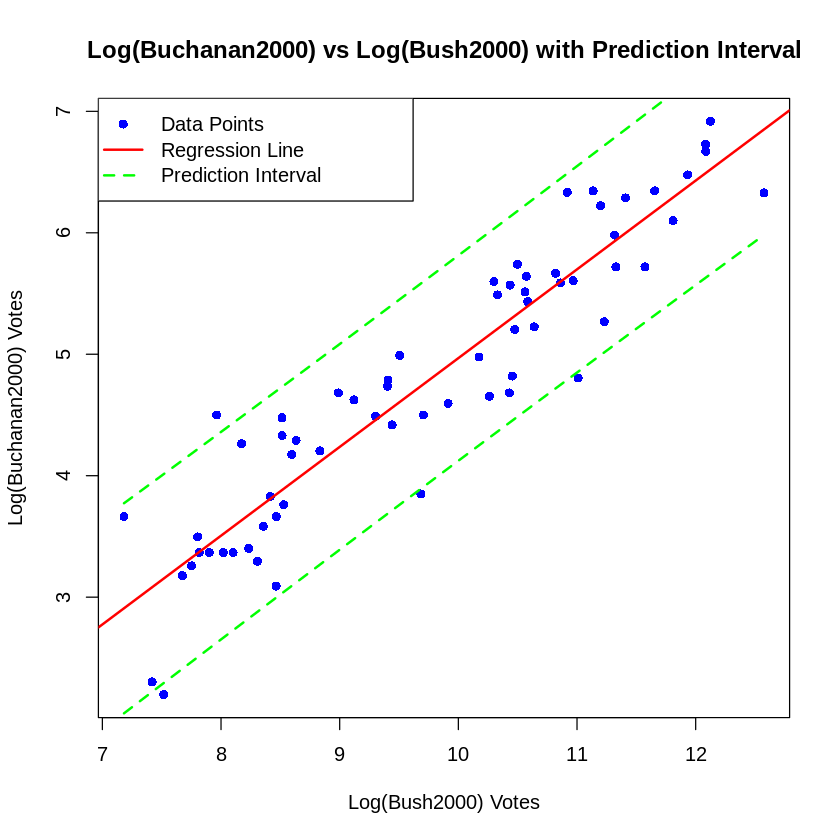

In [ ]:
new_data_logBush <- data.frame(logBush = seq(min(logBush), max(logBush), length.out = 100))

predictions_log_log <- predict(log_log, newdata = new_data_logBush, interval = "prediction")

plot(logBush, logBuchanan,
     main = "Log(Buchanan2000) vs Log(Bush2000) with Prediction Interval",
     xlab = "Log(Bush2000) Votes",
     ylab = "Log(Buchanan2000) Votes",
     col = "blue", pch = 16)

abline(log_log, col = "red", lwd = 2)

lines(new_data_logBush$logBush, predictions_log_log[, "lwr"], col = "green", lty = 2, lwd = 2)
lines(new_data_logBush$logBush, predictions_log_log[, "upr"], col = "green", lty = 2, lwd = 2)

legend("topleft",
       legend = c("Data Points", "Regression Line", "Prediction Interval"),
       col = c("blue", "red", "green"),
       pch = c(16, NA, NA),
       lwd = c(NA, 2, 2),
       lty = c(NA, 1, 2))

In [ ]:
bush_pb <- ex0825$Bush2000[ex0825$County == "Palm Beach"]
log_bush_pb <- log(bush_pb)

# Predict specifically for Palm Beach using the CLEAN model (from step 1)
pred_pb <- predict(log_log,
                   newdata = data.frame(logBush = log_bush_pb),
                   interval = "prediction")

exp(pred_pb)

,fit,lwr,upr
1,592.3769,250.8001,1399.164


In [ ]:
bush_pb <- ex0825$Bush2000[ex0825$County == "Palm Beach"]
log_bush_pb <- log(bush_pb)

# Predict specifically for Palm Beach using the log-log model for a confidence interval
pred_pb_ci <- predict(log_log,
                   newdata = data.frame(logBush = log_bush_pb),
                   interval = "confidence")

# Exponentiate the confidence interval to get it in the original scale
exp(pred_pb_ci)

,fit,lwr,upr
1,592.3769,490.7946,714.9843


In [ ]:
# Get the actual Buchanan vote number for Palm Beach County
palm_beach_buchanan_actual <- ex0825$Buchanan2000[ex0825$County == "Palm Beach"]
palm_beach_buchanan_actual

[1] 3407

I am 95% confident that the Palm Beach Buchanan vote is between 491 and 715. The actual value is 3407. That's a huge difference. This indicates that approximately 2,815 votes may have mistakenly been cast for Buchanan.

#Scope of Inference
This analysis examines county-level voting data from Florida in the 2000 U.S. presidential election. The conclusions apply to the 67 Florida counties, excluding Palm Beach County, when modeling the relationship between Bush and Buchanan votes. The data are observational, so we can identify correlations but cannot claim causation.

By predicting Buchanan votes in Palm Beach based on other counties, we can assess whether the observed count is unusually high. If it falls outside the prediction interval, it suggests, though does not prove, that miscast votes may have occurred due to the ballot design. Overall, the data are suggestive of unusual patterns in Palm Beach County, supporting the hypothesis of voter confusion without definitively proving it.